# MMD Simulations

We design a data generating process for staggered adoption and drop out missingness patterns. 

In [2]:
%load_ext autoreload
%autoreload 2

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

In [7]:
N, T, n, d = 500, 200, 12, 1

In [9]:
Data = np.zeros( (N, T, n, d) )
true_Mean = np.zeros( (N, T, d) )
true_Cov = np.zeros( (N, T, d, d) )

u_1 = np.random.uniform(-5, 5, N)
u_2 = np.random.uniform(0.2, 5, N)

v_1 = np.random.uniform(-5, 5, T)
v_2 = np.random.uniform(0.5, 6, T)

# even_ones = np.repeat([0, 1], d/2)
# odd_ones = np.repeat([1, 0], d/2)

for i in range(N) : 
    for t in range(T) : 
        m_it = np.array([u_1[i]*v_1[t]])
        c_it = np.diag(np.array([(u_2[i]*v_2[t]*(0.5))]))
        print(m_it)
        print(c_it)
        true_Mean[i, t, :] = m_it
        true_Cov[i, t, :, :] = c_it
        dat_mat = np.random.multivariate_normal(m_it, c_it, size = n)
        Data[i, t, :, :] = dat_mat

[0.55077322]
[[8.07662229]]
[0.6533991]
[[8.01659632]]
[-3.22663933]
[[11.60083503]]
[0.65416479]
[[13.20310301]]
[1.29422186]
[[2.28801272]]
[-5.63073375]
[[13.52356905]]
[-3.70711711]
[[1.61710149]]
[1.22220237]
[[2.37950954]]
[3.34156283]
[[5.45876635]]
[6.09453992]
[[9.34470764]]
[-0.35116398]
[[8.61535471]]
[-4.84139427]
[[4.66422894]]
[0.46317924]
[[2.31317972]]
[0.8009957]
[[5.70369283]]
[-4.57693888]
[[3.94519386]]
[-6.23545791]
[[10.60738161]]
[-3.50026037]
[[13.40590461]]
[-1.7695339]
[[2.34306658]]
[-6.1532399]
[[9.73392391]]
[6.18281015]
[[2.58976255]]
[-4.50946807]
[[10.34279254]]
[5.37296676]
[[7.64812925]]
[5.15582914]
[[6.16877315]]
[4.27508101]
[[8.60252472]]
[3.34450288]
[[3.87345337]]
[-0.02740456]
[[12.94134121]]
[5.5269245]
[[10.73433003]]
[-6.34232574]
[[6.87001827]]
[-2.35890067]
[[7.77079977]]
[4.6109045]
[[12.58864646]]
[1.0459554]
[[9.04174224]]
[-5.94706536]
[[7.59066737]]
[-5.96763058]
[[11.84018684]]
[3.35133456]
[[10.36989937]]
[1.9509722]
[[7.239654]]
[-4

In [19]:
expit = lambda x : np.exp(x) / (1 + np.exp(x))
expit

<function __main__.<lambda>(x)>

In [22]:
expit(sum(beta * u_1))

np.float64(0.9999871736101077)

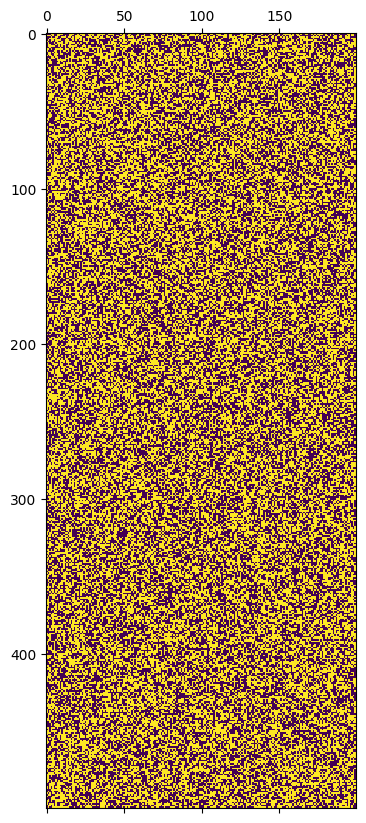

In [10]:
beta = np.repeat((-0.1, 0.2), N/2)
Masking = np.reshape(np.random.binomial( 1, expit(sum(beta * u_1)), (N*T) ), (N, T))
plt.matshow(Masking)

In [61]:
def gendata(N, T, n, d, eps_N, eps_t, p, missing_pattern, num_groups):
  """
  Generate data with missing pattern designated by missing_pattern, r = 3 case
  """
  ## Data Matrix (N * T * n * d)
  Data = np.zeros( (N, T, n, d) )

  u_1 = np.random.uniform(-1, 1, N)
  u_2 = np.random.uniform(0.2, 7, N)
  u_3 = np.random.uniform(0, 1, N)

  v_1 = np.random.uniform(-2, 2, T)
  v_2 = np.random.uniform(0.5, 8, T)
  v_3 = np.random.uniform(0, 1, T)

  for i in range(N) : 
    for t in range(T) : 
        m_u = np.array([u_1[i]])
        m_v = np.array([v_1[t]])
        c_u = np.diag(np.array([u_2[i]*(0.5)]))
        c_v = np.diag(np.array([v_2[t]*(0.5)]))
        # add in r2 (i.e. not mixture)
        mix_weight = u_3[i]/(u_3[i] + v_3[t])
        dat_mat = np.zeros( (n, d) )
        for k in range(n) : 
            comp = np.random.binomial(1, mix_weight)
            if comp == 1 :
                dat_mat[k, :] = np.random.multivariate_normal(m_u, c_u)
            if comp == 0 : 
                dat_mat[k, :] = np.random.multivariate_normal(m_v, c_v)
        Data[i, t, :, :] = dat_mat

  mask = np.zeros((N, T))
  expit = lambda x : np.exp(x)/(1 + np.exp(x))
  beta = np.repeat((-0.1, 0.2), N/2)


  if missing_pattern == "staggered adoption":
    adoption_points = np.arange(0, T + 1)
    #np.array([0, T//4, T//2, 3 * T // 4, np.inf])
    partition_points = np.random.choice(range(1, N), size=num_groups - 1, replace=False)
    partition_points.sort()
    prev = 0
    group_inds = []
    for i in range(num_groups - 1):
       group_inds.append(np.arange(prev, partition_points[i] + 1))
       prev = partition_points[i] + 1
    group_inds.append(np.arange(prev, N))
    start_points = np.random.choice(adoption_points, size = num_groups, replace = True, p = np.full([T + 1], 1 / (T + 1)))
    print(start_points)
    for j, inds in enumerate(group_inds):
       sp_j = start_points[j]
       if sp_j != T:
          # this is mnar non-positive within adopted period
          #mask[inds, sp_j:] = np.random.binomial(1, expit(sum(beta * u_1)), (len(inds), int(T - sp_j)))
          # this is mcar
          mask[inds, sp_j:] = np.random.binomial(1, p, (len(inds), int(T - sp_j)))
  elif missing_pattern == "dropout":
    adoption_points = np.arange(0, T + 1)
    #np.array([0, T//4, T//2, 3 * T // 4, np.inf])
    partition_points = np.random.choice(range(1, N), size=num_groups - 1, replace=False)
    partition_points.sort()
    prev = 0
    group_inds = []
    for i in range(num_groups - 1):
       group_inds.append(np.arange(prev, partition_points[i] + 1))
       prev = partition_points[i] + 1
    group_inds.append(np.arange(prev, N))
    start_points = np.random.choice(adoption_points, size = num_groups, replace = True, p = np.full([T + 1], 1 / (T + 1)))
    # think about how to do the dropout part here
    for j, inds in enumerate(group_inds):
       sp_j = start_points[j]
       if sp_j != T:
          # this is mnar non-positive within adopted period
          #mask[inds, sp_j:] = np.random.binomial(1, expit(sum(beta * u_1)), (len(inds), int(T - sp_j)))
          # this is mcar
          mask[inds, sp_j:] = np.random.binomial(1, p, (len(inds), int(T - sp_j)))
  return Data, mask, group_inds



In [62]:
D, M, ginds = gendata(100, 200, 12, 1, 0.1, 0.1, 0.5, "staggered adoption", 20)

[122  16 139 108 189 143  40 163  48 181 110  52 148 119   8  51 162  88
   3  55]


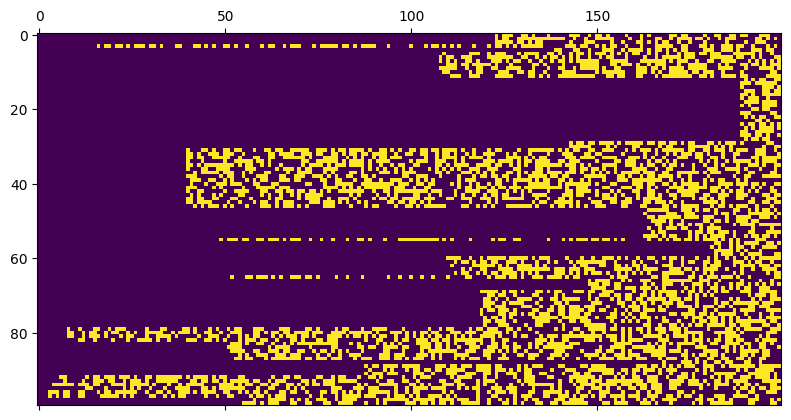

In [63]:
plt.matshow(M)

## Staggered adoption

In [13]:
def expit(x):
    return np.exp(x)/(1 + np.exp(x))

def gendata_s_adopt(N, T, n, d, prop_type = "ind", seed = 42) : 
    """ 
    Generates Gaussian data, with latent dimension r = 2

    required : N, d are both EVEN positive integers
    """
    np.random.seed(seed = seed)
    ## Data Matrix (N * T * n * d)
    Data = np.zeros( (N, T, n, d) )
    true_Mean = np.zeros( (N, T, d) )
    true_Cov = np.zeros( (N, T, d, d) )

    u_1 = np.random.uniform(-2, 5, N)
    u_2 = np.random.uniform(-0.2, 5, N)

    v_1 = np.random.uniform(-5, 5, T)
    v_2 = np.random.uniform(0.5, 6, T)

    for i in range(N) : 
        for t in range(T) : 
            m_it = np.array([u_1[i]*v_1[t]])
            c_it = np.diag(np.array([(u_2[i]*v_2[t]*(0.5))]))
            true_Mean[i, t, :] = m_it
            true_Cov[i, t, :, :] = c_it
            dat_mat = np.random.multivariate_normal(m_it, c_it, size = n)
            Data[i, t, :, :] = dat_mat
    
    Masking = np.zeros( (N, T) )

    g1_inds = np.arange(0, N // 3)
    g2_inds = np.arange(N // 3, 2 * N // 3)
    g3_inds = np.arange(2 * N // 3, N)

    beta_0_g1 = 0.2
    beta_1_g1 = np.array([0.1, -0.4])

    beta_0_g2 = 0.4
    beta_1_g2 = np.array([-0.5, 0.3])
    p_tilde_g1 = np.zeros([len(g1_inds)])
    p_tilde_g2 = np.zeros([len(g2_inds)])


    
    if prop_type == "ind":
        for i in g1_inds:
            p_tilde_g1[i] = expit(beta_0_g1 + beta_1_g1[0] * u_1[i] + beta_1_g1[1] * u_2[i])
            p_tilde_g2[i] = expit(beta_0_g2 + beta_1_g2[0] * u_1[g2_inds[i]] + beta_1_g2[1] * u_2[g2_inds[i]])
        #print(p_tilde_g1)
        #rint(p_tilde_g2)
    elif prop_type == "group":
        group_betas_u1_g1 = np.random.uniform(-0.2, 0.4, len(g1_inds))
        group_betas_u2_g1 = np.random.uniform(-0.6, 0.2, len(g1_inds))

        group_betas_u1_g2 = np.random.uniform(-0.3, 0.4, len(g2_inds))
        group_betas_u2_g2 = np.random.uniform(-0.2, 0.2, len(g2_inds))
        
        p_tilde_group_g1 = expit(beta_0_g1 + (group_betas_u1_g1 @ u_1[g1_inds]) + (group_betas_u2_g1 @ u_2[g1_inds]))
        p_tilde_group_g2 = expit(beta_0_g2 + (group_betas_u1_g2 @ u_1[g2_inds]) + (group_betas_u2_g2 @ u_2[g2_inds]))
        p_tilde_g1 = np.full([len(g1_inds)], p_tilde_group_g1)
        p_tilde_g2 = np.full([len(g2_inds)], p_tilde_group_g2)
        #sum_g1 += beta_1_g1 * u_1[i] + 
    #full_p_g1 = np.full([len(g1_inds), T], p_tilde_ind_g1)
    #full_p_g2 = np.full([len(g2_inds), T], p_tilde_ind_g2) 
    full_p_g1 = np.tile(p_tilde_g1[:,None].T, (T // 2, 1)).T
    full_p_g2 = np.tile(p_tilde_g2[:, None].T, (T // 3, 1)).T
    A_tilde_g1 = np.random.binomial(1, full_p_g1, (len(g1_inds), T // 2))
    A_tilde_g2 = np.random.binomial(1, full_p_g2, (len(g2_inds), T // 3))

    # while np.all(A_tilde_g1 == 0):
    #     A_tilde_g1 = np.random.binomial(1, full_p_g1, (len(g1_inds), T // 2))
    # while np.all(A_tilde_g2 == 0):
    #     A_tilde_g2 = np.random.binomial(1, full_p_g2, (len(g2_inds), T // 3))

    A_g1 = np.ones([len(g1_inds), T])
    A_g2 = np.ones([len(g2_inds), T])
    for i in range(len(g1_inds)):
        if np.all(A_tilde_g1[i] == 0):
            tau_g1 = T // 2
        else:
            tau_g1 = np.nonzero(A_tilde_g1[i] == 1)[0][0] + (T // 2)
        
        if np.all(A_tilde_g2[i] == 0):
            tau_g2 = 2 * T // 3
        else:
            tau_g2 = np.nonzero(A_tilde_g2[i] == 1)[0][0] + (2 * T // 3)
        A_g1[i, tau_g1:] = 0
        A_g2[i, tau_g2:] = 0

    A_g3 = np.ones([len(g3_inds), T])

    Masking = np.zeros([N, T])
    Masking[g1_inds] = A_g1
    Masking[g2_inds] = A_g2
    Masking[g3_inds] = A_g3

    return(Data, Masking, true_Mean, true_Cov)

In [17]:
D, M, true_Mean, true_Cov = gendata_s_adopt(N, T, n, d, "ind")

/var/folders/51/5b2yypxn6qj7ntrpl0x8kcvm0000gn/T/ipykernel_35659/428671291.py:28: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  dat_mat = np.random.multivariate_normal(m_it, c_it, size = n)


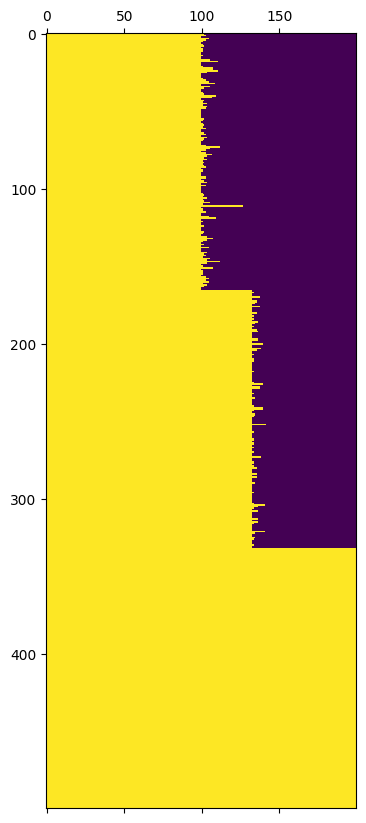

In [18]:
plt.matshow(M)

## Rollout

In [4]:
def expit(x):
    return np.exp(x)/(1 + np.exp(x))

def gendata_rollout(N, T, n, d, seed = 42) : 
    """ 
    Generates Gaussian data, with latent dimension r = 2

    required : N, d are both EVEN positive integers
    """
    np.random.seed(seed = seed)
    ## Data Matrix (N * T * n * d)
    Data = np.zeros( (N, T, n, d) )
    true_Mean = np.zeros( (N, T, d) )
    true_Cov = np.zeros( (N, T, d, d) )

    u_1 = np.random.uniform(-2, 5, N)
    u_2 = np.random.uniform(-0.2, 5, N)

    v_1 = np.random.uniform(-5, 5, T)
    v_2 = np.random.uniform(0.5, 6, T)

    for i in range(N) : 
        for t in range(T) : 
            m_it = np.array([u_1[i]*v_1[t]])
            c_it = np.diag(np.array([(u_2[i]*v_2[t]*(0.5))]))
            true_Mean[i, t, :] = m_it
            true_Cov[i, t, :, :] = c_it
            dat_mat = np.random.multivariate_normal(m_it, c_it, size = n)
            Data[i, t, :, :] = dat_mat
    
    Masking = np.zeros( (N, T) )

    g1_inds = np.arange(0, N // 3)
    g2_inds = np.arange(N // 3, 2 * N // 3)
    g3_inds = np.arange(2 * N // 3, N)

    beta_0_g1 = 0.2
    beta_1_g1 = np.array([0.1, -0.4])

    beta_0_g2 = 0.4
    beta_1_g2 = np.array([-0.5, 0.3])

    beta_0_g3 = 0.1
    beta_1_g3 = np.array([0.3, -0.2])

    p_tilde_g1 = np.zeros([len(g1_inds), T])
    p_tilde_g2 = np.zeros([len(g2_inds), T])
    p_tilde_g3 = np.zeros([len(g3_inds), T])
    dr = np.array([0.025, 0.04, 0.01])
    p_lb = np.array([0.1, 0.25, 0.5])
    
    for t in range(T):
        for i in range(len(g1_inds)):
            p_tilde_g1[i, t] = expit(beta_0_g1 + beta_1_g1[0] * u_1[i] + beta_1_g1[1] * u_2[i] - (t * dr[0]))
        for j in range(len(g2_inds)):
            p_tilde_g2[j, t] = expit(beta_0_g2 + beta_1_g2[0] * u_1[j] + beta_1_g2[1] * u_2[j] - (t * dr[1]))
        for k in range(len(g3_inds)):
            p_tilde_g3[k, t] = expit(beta_0_g3 + beta_1_g3[0] * u_1[k] + beta_1_g3[1] * u_2[k] - (t * dr[2]))
         
    # p_tilde_g2[i, t] = expit(beta_0_g2 + beta_1_g2[0] * u_1[g2_inds[i]] + beta_1_g2[1] * u_2[g2_inds[i]] - (t * dr[1]))
    #         p_tilde_g3[i, t] = expit(beta_0_g3 + beta_1_g3[0] * u_1[g3_inds[i]] + beta_1_g3[1] * u_2[g3_inds[i]] - (t * dr[2]))
    # full_p_g1 = np.tile(p_tilde_g1[:,None].T, (T // 2, 1)).T
    # full_p_g2 = np.tile(p_tilde_g2[:, None].T, (T // 2, 1)).T
    p_tilde_g1 = np.clip(p_tilde_g1, a_min = p_lb[0], a_max = None)
    p_tilde_g2 = np.clip(p_tilde_g2, a_min = p_lb[1], a_max = None)
    p_tilde_g3 = np.clip(p_tilde_g3, a_min = p_lb[2], a_max = None)

    A_g1 = np.random.binomial(1, p_tilde_g1, (len(g1_inds), T))
    A_g2 = np.random.binomial(1, p_tilde_g2, (len(g2_inds), T))
    A_g3 = np.random.binomial(1, p_tilde_g3, (len(g3_inds), T))

    # A_g1 = np.ones([len(g1_inds), T])
    # A_g2 = np.ones([len(g2_inds), T])
    # for i in range(len(g1_inds)):
    #     tau_g1 = np.nonzero(A_tilde_g1[i] == 1)[0][0] + (T // 2)
    #     tau_g2 = np.nonzero(A_tilde_g2[i] == 1)[0][0] + (T // 2)
    #     A_g1[i, tau_g1:] = 0
    #     A_g2[i, tau_g2:] = 0

    Masking = np.ones([N, T])
    Masking[g1_inds, :] = A_g1
    Masking[g2_inds, :] = A_g2
    Masking[g3_inds, :] = A_g3

    return(Data, Masking, true_Mean, true_Cov)

In [5]:
D, M , _, _ = gendata_rollout(256, 100, 12, 1)

NameError: name 'np' is not defined

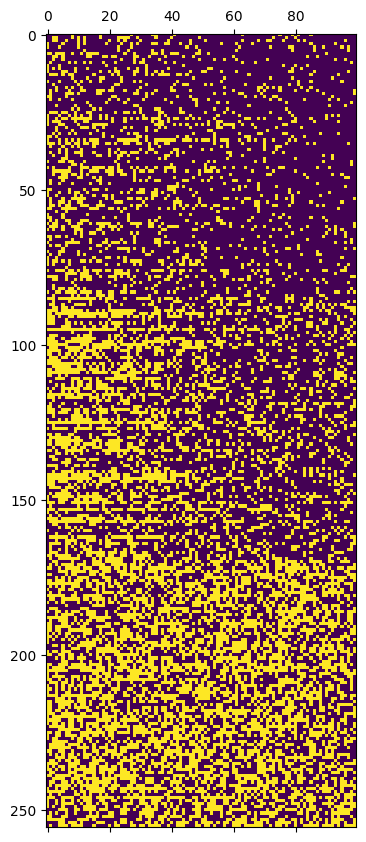

In [80]:
plt.matshow(M)

In [6]:
%cd ../src

c:\Users\Caleb\HeartstepsDNN\src


c:\Users\Caleb\HeartstepsDNN\Heartsteps-DNN\dnn_env\Lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


## MCAR Missingness

In [19]:
# def expit(x):
#     return np.exp(x)/(1 + np.exp(x))

def gendata_mcar(N, T, n, d, p = 0.5, seed = 42) : 
    """ 
    Generates Gaussian data, with latent dimension r = 2

    required : N, d are both EVEN positive integers
    """
    np.random.seed(seed = seed)
    ## Data Matrix (N * T * n * d)
    Data = np.zeros( (N, T, n, d) )
    true_Mean = np.zeros( (N, T, d) )
    true_Cov = np.zeros( (N, T, d, d) )

    u_1 = np.random.uniform(-2, 5, N)
    u_2 = np.random.uniform(-0.2, 5, N)

    v_1 = np.random.uniform(-5, 5, T)
    v_2 = np.random.uniform(0.5, 6, T)

    for i in range(N) : 
        for t in range(T) : 
            m_it = np.array([u_1[i]*v_1[t]])
            c_it = np.diag(np.array([(u_2[i]*v_2[t]*(0.5))]))
            true_Mean[i, t, :] = m_it
            true_Cov[i, t, :, :] = c_it
            dat_mat = np.random.multivariate_normal(m_it, c_it, size = n)
            Data[i, t, :, :] = dat_mat
    
    Masking = np.zeros( (N, T) )
    Masking = np.reshape(np.random.binomial( 1, p, (N*T) ), (N, T))
   

    return(Data, Masking, true_Mean, true_Cov)

In [24]:
D, M, true_mean, true_cov = gendata_mcar(200, 200, 12, 2, 0.5)

/var/folders/51/5b2yypxn6qj7ntrpl0x8kcvm0000gn/T/ipykernel_35659/4530664.py:28: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  dat_mat = np.random.multivariate_normal(m_it, c_it, size = n)


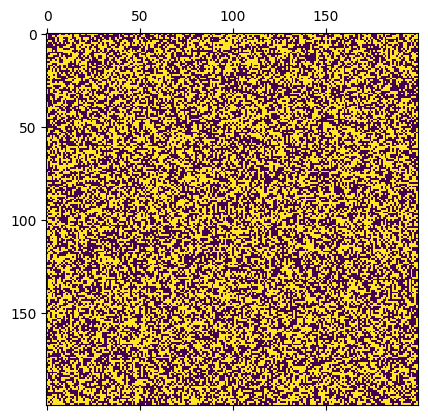

In [25]:
plt.matshow(M)

## Experiments

### MCAR experiment for demonstration

In [29]:
%cd ../src
from kernel_nn import KernelNN
from hyperopt import hp

/Users/calebchin/Documents/DistributionalNearestNeighbors/.venv/lib/python3.9/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


/Users/calebchin/Documents/DistributionalNearestNeighbors/src


First, define the NN object of your choice. We use KernelNN for these experiments. We want a gaussian/exponential kernel for this experiment, so we use `kernel = "exponential"`. We use unit/row nearest neighbors, so we set ``nn_type`` to "uu". We wish to implement simple two fold cross validation without row-specific eta-tuning, so we set `k = 2` and `eta_axis = -1`.

In [30]:
knn_ss = KernelNN(kernel = "exponential", nn_type = "uu", k = 2, eta_axis=-1, rand_seed=42)

We also need to set a search space for the neighborhood radius parameter 'eta'. To do this, we can compute the maximum distance between rows of our data. The default hyperparameter search algorithm is the Tree-structured Parzen Estimator (TPE), which will select areas of the search space with a high probability of minimizing the objective function, so setting the search space to the maximum range is recommended. 

In [31]:
Z, M, true_Mean, true_Cov = gendata_rollout(32, 90, 10, 2, seed = 42)
dists = knn_ss.distances(Z, M)
print(np.max(dists[np.logical_and(~np.isinf(dists), ~np.isnan(dists))]))

1.7292396479593664


/var/folders/51/5b2yypxn6qj7ntrpl0x8kcvm0000gn/T/ipykernel_35659/1375333302.py:28: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  dat_mat = np.random.multivariate_normal(m_it, c_it, size = n)
/Users/calebchin/Documents/DistributionalNearestNeighbors/src/kernel_nn.py:125: RuntimeWarning: Mean of empty slice
  val = np.nanmean(val_all)


So we can set the eta space from 0 to 2.

In [32]:
knn_ss.set_etaspace(hp.uniform('eta', 0, 2))

Now, we can proceed with our experiment. We increase the size of the matrix (N grows) and visualize the error decay.

In [43]:
from tqdm import tqdm

In [ ]:
#**** Varying N ******
T, n, d = 60, 10, 2
p = 0.5
# eta_pool = np.arange(1, 30, 0.5)/3 # used for MNAR + non-positive
#eta_pool = np.append(np.arange(0, 3, 0.2), np.arange(3, 6, 0.4)) # used for MCAR
missing_patterns = ["mcar"]
i, t = 0, T - 1
nsim = 30
# print(f"{0}-th iteration")
mp_num = 0
for missing_pattern in missing_patterns:
    print(missing_pattern)
    pools = []
    pools_eta = []
    for j, row_exp in enumerate(np.arange(5, 9)): 
        # print("row size", row_exp)
        N = 2**(row_exp)
        inds = (np.array([0, N // 2, N - 1]), np.array([T - 1, T // 2, 0]))
        flat_inds = [(0, T - 1), (N // 2, T // 2), (N - 1, 0)]
        perf_pool, eta_star_pool = np.full( nsim, np.nan ), np.full(nsim, np.nan)
        print(f"{j}-th iteration")
        print("N = " + str(N))
        for sim in tqdm(range(nsim)):
            # generate data matrices
            if missing_pattern == "mcar":
                Z, M, true_Mean, true_Cov = gendata_mcar(N, T, n, d, p, seed = sim)
                save_perf = "perf_mcar.npy"
                save_eta = "eta_mcar.npy"
            elif missing_pattern == "sa":
                Z, M, true_Mean, true_Cov = gendata_s_adopt(N, T, n, d, prop_type = "ind", seed = sim)
                save_perf = "perf_sa_ind.npy"
                save_eta = "eta_sa_ind.npy"
            elif missing_pattern == "rollout":
                Z, M, _, _ = gendata_rollout(N, T, n, d, seed = sim)
                save_file = "perf_rollout.npy"
                save_eta = "eta_rollout.npy"
            # mask out entry to estimate
            M[inds] = 0
            # compute distances using the distances function
            dists = knn_ss.distances(Z, M)
            # search for neighborhood parameter using the search_eta function, note: the inds argument is not used for two-fold block cv
            eta_star = knn_ss.search_eta(Z, M, max_evals = 30, inds = None, dists = dists, verbose=False)
            eta_star_pool[sim] = eta_star
            # estimate the missing entries using the estimate function
            est = knn_ss.estimate(Z, M, eta_star, flat_inds, dists)

            truth_samples = []
            est_use = []
            for i, t in flat_inds:
                true_Mean_it = true_Mean[i, t, :]
                true_Cov_it = true_Cov[i, t, :, :]
                truth_samples.append(np.random.multivariate_normal(true_Mean_it, true_Cov_it, size = N * n))
                est_use.append(est[i][t])
            # compute error of estimate using avg_error
            perf = knn_ss.avg_error(est_use, truth_samples, np.arange(len(truth_samples)))
            perf_pool[sim] = perf
        pools_eta.append(eta_star_pool)
        pools.append(perf_pool)
    np.save(save_perf, np.array(pools, dtype = object), allow_pickle=True)
    np.save(save_eta, np.array(pools_eta, dtype = object), allow_pickle = True)


mcar
0-th iteration
N = 32


  0%|          | 0/30 [00:00<?, ?it/s]/var/folders/51/5b2yypxn6qj7ntrpl0x8kcvm0000gn/T/ipykernel_35659/4530664.py:28: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  dat_mat = np.random.multivariate_normal(m_it, c_it, size = n)
 73%|███████▎  | 22/30 [01:14<00:26,  3.33s/it]/var/folders/51/5b2yypxn6qj7ntrpl0x8kcvm0000gn/T/ipykernel_35659/3804254256.py:52: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  truth_samples.append(np.random.multivariate_normal(true_Mean_it, true_Cov_it, size = N * n))
100%|██████████| 30/30 [01:41<00:00,  3.38s/it]


1-th iteration
N = 64


100%|██████████| 30/30 [06:40<00:00, 13.36s/it]


2-th iteration
N = 128


100%|██████████| 30/30 [37:20<00:00, 74.67s/it]


3-th iteration
N = 256


100%|██████████| 30/30 [12:09:57<00:00, 1459.92s/it]  


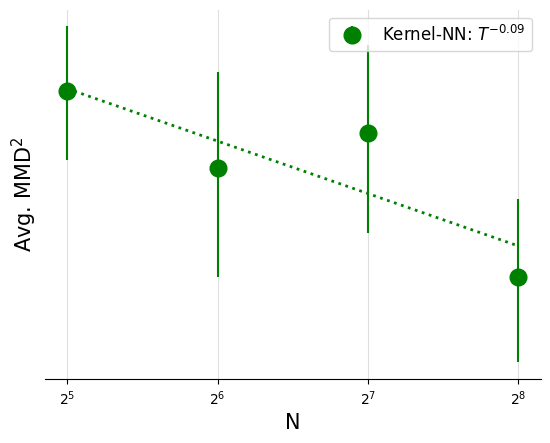

In [59]:
import matplotlib.pyplot as plt

dnn_err = np.array(pools)
# Define T values and corresponding error rates for each method
T_values = np.array([2**5, 2**6, 2**7, 2**8])

dnn_errors = np.nanmean(dnn_err, axis = 1)
dnn_stderr = np.nanstd(dnn_err, axis = 1) / np.sqrt(dnn_err.shape[1])



# Create the plot
plt.figure()
#plt.plot(T_values, USVT_errors, 'r', linestyle='-', marker='D', markersize=8, linewidth=2, label=r'USVT: $T^{-0.46}$')

def add_regression_line(x, y, color, label, linestyle):
    # Fit a line to log-transformed data
    slope, intercept = np.polyfit(np.log2(x), np.log2(y), 1)
    plt.plot(x, 2**(intercept) * x**slope, color=color, linestyle=linestyle, linewidth=2) 
             #label=f"{label} (slope: {slope:.2f})")
    return slope

dnn_slope = add_regression_line(T_values, dnn_errors, 'green', 'User-NN', ':')


# Plot each method with corresponding markers, colors, and line styles
plt.errorbar(T_values, dnn_errors, yerr=dnn_stderr, fmt = 'g', marker='o', markersize=12, linestyle='None', label=rf'Kernel-NN: $T^{{{dnn_slope:.2f}}}$')

# Logarithmic scale for both axes
plt.xscale('log', base=2)
plt.yscale('log', base=2)

# Axis labels
plt.xlabel(r'N', fontsize=15)
plt.ylabel(r'Avg. MMD$^2$', fontsize=15)

# Title
#plt.title(r'Decay of avg. error across users (N = T, 30 trials)', fontsize=16)

# Add legend
plt.legend(fontsize=12)

# Grid for better readability
#plt.grid(True, which="both", linestyle='--', linewidth=0.5)
ax1 = plt.gca()
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_visible(False)
ax1.grid(True, alpha=0.4)


# Show the plot#
plt.savefig("dnn_err_trial.pdf", bbox_inches = "tight")


In [ ]:
#**** Varying N ******
T, n, d = 60, 10, 2
p = 0.5
# eta_pool = np.arange(1, 30, 0.5)/3 # used for MNAR + non-positive
#eta_pool = np.append(np.arange(0, 3, 0.2), np.arange(3, 6, 0.4)) # used for MCAR
missing_patterns = ["rollout"]  
i, t = 0, T - 1
nsim = 30
# print(f"{0}-th iteration")
mp_num = 0
for missing_pattern in missing_patterns:
    print(missing_pattern)
    pools = []
    pools_eta = []
    for j, row_exp in enumerate(np.arange(5, 9)): 
        
        # print("row size", row_exp)
        N = 2**(row_exp)
        perf_pool, eta_star_pool = np.full( nsim, np.nan ), np.full(nsim, np.nan)
        print(f"{j}-th iteration")
        print("N = " + str(N))
        for sim in range(nsim):
            if missing_pattern == "mcar":
                Z, M, true_Mean, true_Cov = gendata_mcar(N, T, n, d, p, seed = sim)
                save_perf = "perf_mcar.npy"
                save_eta = "eta_mcar.npy"
            if missing_pattern == "sa":
                Z, M, true_Mean, true_Cov = gendata_s_adopt(N, T, n, d, prop_type = "ind", seed = sim)
                save_perf = "perf_sa_ind.npy"
                save_eta = "eta_sa_ind.npy"
            elif missing_pattern == "rollout":
                Z, M, _, _ = gendata_rollout(N, T, n, d, seed = sim)
                save_file = "perf_rollout.npy"
                save_eta = "eta_rollout.npy"
            # true_Mean_it = true_Mean[i, t, :]
            # true_Cov_it = true_Cov[i, t, :, :]

            dists = knn_ss.distances(Z, M)
            eta_star = knn_ss.search_eta(Z, M, max_evals = 30, inds = i, dists = dists)
            eta_star_pool[sim] = eta_star

            est = knn_ss.estimate(Z, M, eta_star, [(i, t)], dists)
            est_use = est[i]
            perf = knn_ss.avg_error(est_use, Z[i], np.array([t]))
            perf_pool[sim] = perf
        pools_eta.append(eta_star_pool)
        pools.append(perf_pool)
    np.save(save_perf, np.array(pools, dtype = object), allow_pickle=True)
    np.save(save_eta, np.array(pools_eta, dtype = object), allow_pickle = True)


rollout
0-th iteration
N = 32


C:\Users\Caleb\AppData\Local\Temp\ipykernel_22720\1375333302.py:28: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  dat_mat = np.random.multivariate_normal(m_it, c_it, size = n)
c:\Users\Caleb\HeartstepsDNN\src\kernel_nn.py:125: RuntimeWarning: Mean of empty slice
  val = np.nanmean(val_all)


100%|██████████| 30/30 [00:16<00:00,  1.85trial/s, best loss: 0.11206376389571135]
1-th iteration
N = 64
100%|██████████| 30/30 [00:11<00:00,  2.52trial/s, best loss: 0.13865964099725273]
2-th iteration
N = 128
100%|██████████| 30/30 [01:05<00:00,  2.19s/trial, best loss: 0.1336318396120465]
3-th iteration
N = 256
 87%|████████▋ | 26/30 [12:09<02:30, 37.68s/trial, best loss: 0.12235333495656714]